In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('boat_data.csv')

print('Libraries imported.')
print('Dataset loaded.')
print(f'Shape: {df.shape[0]} rows, {df.shape[1]} columns')


Libraries imported.
Dataset loaded.
Shape: 9888 rows, 10 columns


In [2]:
print('=== Shape ===')
print(f'{df.shape[0]} rows and {df.shape[1]} columns')

print('\n=== Column Names ===')
print(df.columns.tolist())

print('\n=== Data Types ===')
print(df.dtypes)

print('\n1st 5 row')
df.head()

print('\n=== Summary Statistics ===')
df.describe()

print('\n=== Missing Value Summary ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])


=== Shape ===
9888 rows and 10 columns

=== Column Names ===
['Price', 'Boat Type', 'Manufacturer', 'Type', 'Year Built', 'Length', 'Width', 'Material', 'Location', 'Number of views last 7 days']

=== Data Types ===
Price                              str
Boat Type                          str
Manufacturer                       str
Type                               str
Year Built                       int64
Length                         float64
Width                          float64
Material                           str
Location                           str
Number of views last 7 days      int64
dtype: object

1st 5 row

=== Summary Statistics ===

=== Missing Value Summary ===
              Missing Count  Missing %
Manufacturer           1338      13.53
Type                      6       0.06
Length                    9       0.09
Width                    56       0.57
Material               1749      17.69
Location                 36       0.36


In [4]:
df_clean = df.copy()

exchange_rates = {
    'EUR': 1.08,
    'CHF': 1.11,
    'GBP': 1.27,
    'DKK': 0.145,
    'USD': 1.0,
    '$':   1.0,
}

def convert_price_to_usd(price_str):
    """Extract numeric value and convert to USD."""
    if pd.isnull(price_str):
        return np.nan
    price_str = str(price_str).replace(',', '').replace("'", '').strip()
    currency = None
    for key in exchange_rates:
        if key in price_str:
            currency = key
            break
    # Remove all non-numeric characters
    numeric = ''.join(c for c in price_str if c.isdigit() or c == '.')
    if not numeric:
        return np.nan
    value = float(numeric)
    rate = exchange_rates.get(currency, 1.0)
    return round(value * rate, 2)

df_clean['Price_USD'] = df_clean['Price'].apply(convert_price_to_usd)
print('***** Price converted to USD.')
print(f'Price_USD sample: {df_clean["Price_USD"].dropna().head().values}')


***** Price converted to USD.
Price_USD sample: [3704.07 3769.2  4184.7  3755.5  3670.92]


In [7]:
df_clean['Country'] = df_clean['Location'].str.split('»').str[0].str.strip()
df_clean['Country'] = df_clean['Country'].str.replace('Â', '').str.strip()

print('***** Country column extracted.')
print('Top countries:')
print(df_clean['Country'].value_counts().head(8))

***** Country column extracted.
Top countries:
Country
Germany               1913
Italy                 1793
France                1227
Switzerland           1110
Netherlands           1056
Croatia (Hrvatska)     810
Spain                  702
United Kingdom         215
Name: count, dtype: int64


In [8]:
df_clean['Material'] = df_clean['Material'].fillna('Unknown')
df_clean['Type'] = df_clean['Type'].fillna('Unknown')
df_clean = df_clean.dropna(subset=['Year Built', 'Length', 'Price_USD'])
df_clean['Width'] = df_clean['Width'].fillna(df_clean['Width'].median())

print('***** Missing values handled.')
print(f'Remaining rows: {len(df_clean)}')

***** Missing values handled.
Remaining rows: 9879


In [10]:
before = len(df_clean)
df_clean = df_clean[(df_clean['Price_USD'] >= 10) & (df_clean['Price_USD'] <= 10_000_000)]
after = len(df_clean)
print(f'***** Removed {before - after} rows with unrealistic prices.')
print(f'Final clean dataset: {after} rows')

***** Removed 0 rows with unrealistic prices.
Final clean dataset: 9859 rows


In [11]:
# Feature 1: Boat Age - Derived from Year Built. Older boats generally depreciate more.
df_clean['Boat Age'] = 2024 - df_clean['Year Built'].astype(int)
print('Feature 1 — Boat Age created.')
print(df_clean['Boat Age'].describe())

Feature 1 — Boat Age created.
count    9859.000000
mean      130.340704
std       459.257906
min         3.000000
25%         7.000000
50%        17.000000
75%        28.000000
max      2024.000000
Name: Boat Age, dtype: float64


In [12]:
# Feature 2: Price per Meter - Shows value density — is the boat expensive for its size?
df_clean['Price per Meter'] = (df_clean['Price_USD'] / df_clean['Length']).round(2)
print('Feature 2 — Price per Meter created.')
print(df_clean['Price per Meter'].describe())

Feature 2 — Price per Meter created.
count    9.859000e+03
mean     1.818396e+04
std      3.943792e+04
min      1.566000e+02
25%      5.736005e+03
50%      1.008000e+04
75%      2.027492e+04
max      2.561143e+06
Name: Price per Meter, dtype: float64


In [13]:
# Feature 3: Boat Category - Groups Boat Type into 3 broader categories for easier comparison
sailboat_types = ['Sailboat', 'Sailing yacht', 'Catamaran']
powerboat_types = ['Motor yacht', 'Motorboat', 'Sport boat', 'Cabin boat', 'Bowrider']

def categorize_boat(boat_type):
    if pd.isnull(boat_type):
        return 'Other'
    for s in sailboat_types:
        if s.lower() in str(boat_type).lower():
            return 'Sailboat'
    for p in powerboat_types:
        if p.lower() in str(boat_type).lower():
            return 'Powerboat'
    return 'Other'

df_clean['Boat Category'] = df_clean['Boat Type'].apply(categorize_boat)
print('Feature 3 — Boat Category created.')
print(df_clean['Boat Category'].value_counts())

Feature 3 — Boat Category created.
Boat Category
Powerboat    5199
Other        4634
Sailboat       26
Name: count, dtype: int64


In [14]:
# Analysis 1: Average price by Boat Category (Subgroup Comparison 1) - tells us whether sailboats or powerboats command higher prices on average.
print('=== Avg Price (USD) by Boat Category ===')
cat_price = df_clean.groupby('Boat Category')['Price_USD'].mean().sort_values(ascending=False).round(2)
print(cat_price)

=== Avg Price (USD) by Boat Category ===
Boat Category
Sailboat     773334.85
Other        316493.85
Powerboat    261881.79
Name: Price_USD, dtype: float64


In [15]:
# Analysis 2: Average price by Country (Subgroup Comparison 2)
print('=== Top 10 Countries by Avg Price (USD) ===')
country_price = df_clean.groupby('Country')['Price_USD'].mean().sort_values(ascending=False).head(10).round(2)
print(country_price)

=== Top 10 Countries by Avg Price (USD) ===
Country
Philippines                      4917240.0
Australia                        4732497.5
United Arab Emirates             4603212.0
Taiwan                           4590000.0
Luxembourg                       2052000.0
Thailand                         2035080.0
Monaco                           1373040.0
Venezuela                        1285200.0
Neustadt in Holstein (Ostsee)    1024920.0
Bulgaria                          978480.0
Name: Price_USD, dtype: float64


In [19]:
# Analysis 3: Relationship between Length and Price
print('=== Correlation: Length vs Price_USD ===')
correlation = df_clean['Length'].corr(df_clean['Price_USD'])
print(f'Pearson correlation coefficient: {correlation:.4f}')

=== Correlation: Length vs Price_USD ===
Pearson correlation coefficient: 0.6163


In [20]:
# --- Analysis 4: Outlier detection using NumPy Z-scores - extremely priced boats are statistical anomalies and may be luxury yachts or data errors.
z_scores = np.abs((df_clean['Price_USD'] - df_clean['Price_USD'].mean()) / df_clean['Price_USD'].std())
outliers = df_clean[z_scores > 3]
print(f'=== Price Outliers (Z-score > 3) ===')
print(f'Number of outlier listings: {len(outliers)}')
print(f'Min outlier price: ${outliers["Price_USD"].min():,.0f}')
print(f'Max outlier price: ${outliers["Price_USD"].max():,.0f}')

=== Price Outliers (Z-score > 3) ===
Number of outlier listings: 166
Min outlier price: $2,343,600
Max outlier price: $9,995,000


In [21]:
# Analysis 5: NumPy custom computation — price percentile ranking - help classify boats as budget, mid-range, or premium listings.
print('=== Price Percentile Thresholds ===')
percentiles = [25, 50, 75, 90, 95]
for p in percentiles:
    val = np.percentile(df_clean['Price_USD'], p)
    print(f'  {p}th percentile: ${val:,.0f}')

=== Price Percentile Thresholds ===
  25th percentile: $46,386
  50th percentile: $99,360
  75th percentile: $264,600
  90th percentile: $605,640
  95th percentile: $1,058,770


In [22]:
# Analysis 6: Views by Boat Category
print('=== Avg Views (last 7 days) by Boat Category ===')
views_by_cat = df_clean.groupby('Boat Category')['Number of views last 7 days'].mean().sort_values(ascending=False).round(1)
print(views_by_cat)

=== Avg Views (last 7 days) by Boat Category ===
Boat Category
Sailboat     165.5
Powerboat    165.1
Other        130.6
Name: Number of views last 7 days, dtype: float64


In [23]:
# Analysis 7: Top 10 manufacturers by average price
print('=== Top 10 Manufacturers by Avg Price ===')
mfr_price = df_clean.groupby('Manufacturer')['Price_USD'].mean().sort_values(ascending=False).head(10).round(2)
print(mfr_price)

=== Top 10 Manufacturers by Avg Price ===
Manufacturer
Cantiere delle Marche power boats           9504000.00
Curvelle power boats                        9018000.00
Abeking & Rasmussen power boats             6480000.00
Rodriguez Group (Italyachts) power boats    6372000.00
Palmer Johnson power boats                  5184000.00
Majesty Yachts power boats                  5040600.92
Perini Navi Spa power boats                 4968000.00
Bandido Yachts power boats                  4480650.00
Couach power boats                          4212000.00
ISA Yachts power boats                      4158000.00
Name: Price_USD, dtype: float64


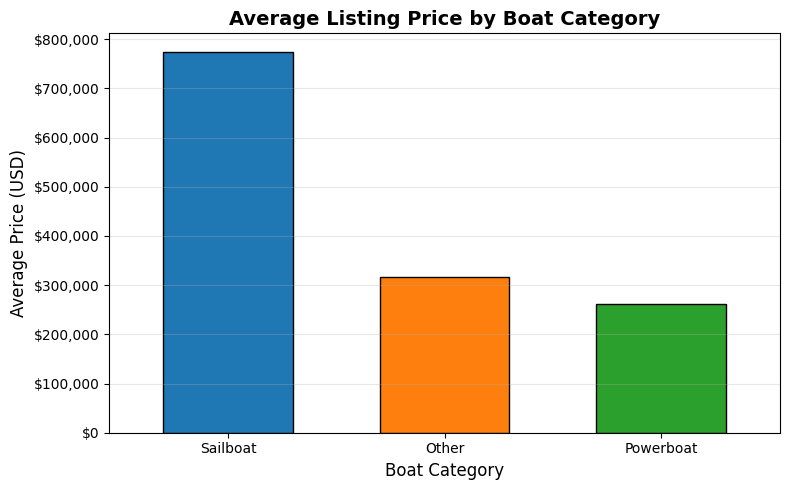

CHART 1 INTERPRETATION:
This bar chart compares the average listing price across the three boat categories.
It directly answers Question 1: whether sailboats or powerboats command higher prices.
The taller the bar, the more expensive boats in that category tend to be on average.


In [24]:
## --- Chart 1: Average Price by Boat Category (Bar Chart) ---
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
cat_price.plot(kind='bar', ax=ax, color=colors, edgecolor='black', width=0.6)
ax.set_title('Average Listing Price by Boat Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Boat Category', fontsize=12)
ax.set_ylabel('Average Price (USD)', fontsize=12)
ax.set_xticklabels(cat_price.index, rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart1_price_by_category.png', dpi=150)
plt.show()
print('CHART 1 INTERPRETATION:')
print('This bar chart compares the average listing price across the three boat categories.')
print('It directly answers Question 1: whether sailboats or powerboats command higher prices.')
print('The taller the bar, the more expensive boats in that category tend to be on average.') 

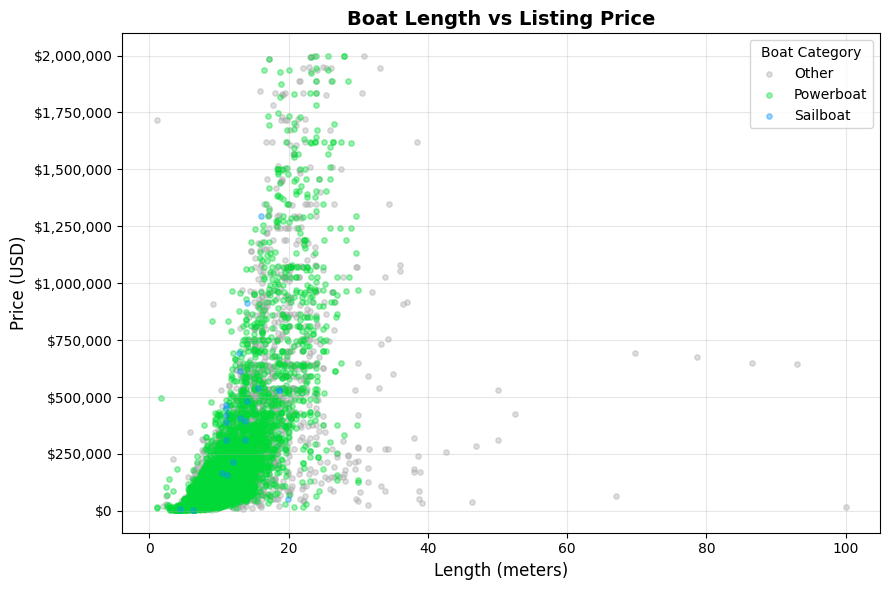

CHART 2 INTERPRETATION:
This scatter plot shows the relationship between boat length and price.
An upward trend would confirm that larger boats are priced significantly higher.
The color coding reveals whether this trend holds differently for sailboats vs powerboats.


In [26]:

# Chart 2: Length vs Price (Scatter Plot)
fig, ax = plt.subplots(figsize=(9, 6))
colors_map = {'Sailboat': "#0095ff", 'Powerboat': "#00db37", 'Other': '#aaaaaa'}
for category, group in df_clean[df_clean['Price_USD'] < 2_000_000].groupby('Boat Category'):
    ax.scatter(group['Length'], group['Price_USD'],
               label=category, alpha=0.4, s=15,
               color=colors_map.get(category, '#888888'))
ax.set_title('Boat Length vs Listing Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Length (meters)', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Boat Category')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart2_length_vs_price.png', dpi=150)
plt.show()
print('CHART 2 INTERPRETATION:')
print('This scatter plot shows the relationship between boat length and price.')
print('An upward trend would confirm that larger boats are priced significantly higher.')
print('The color coding reveals whether this trend holds differently for sailboats vs powerboats.')

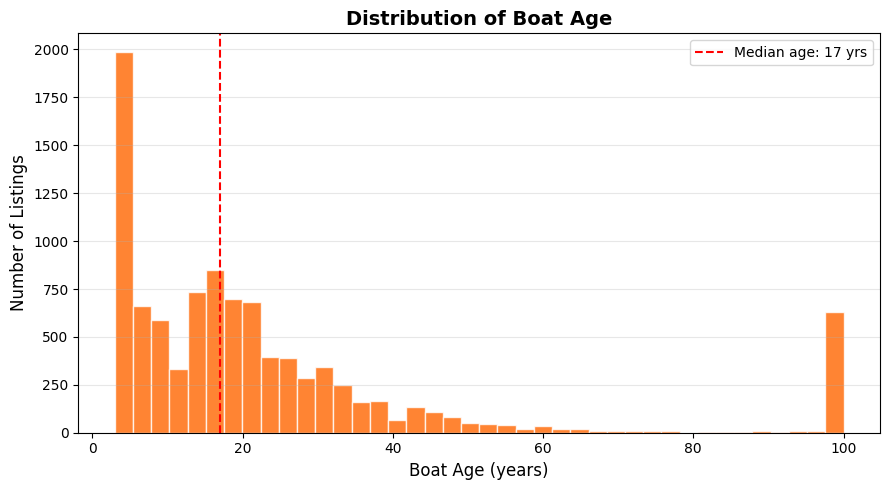

CHART 3 INTERPRETATION:
This histogram shows how old the listed boats are.
A right-skewed distribution would indicate that most boats listed are relatively young.
The red median line gives a quick reference for what a typical listing age looks like.


In [29]:
# Chart 3: Boat Age Distribution (Histogram)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_clean['Boat Age'].clip(0, 100), bins=40, color="#ff6600", edgecolor='white', alpha=0.8)
ax.set_title('Distribution of Boat Age', fontsize=14, fontweight='bold')
ax.set_xlabel('Boat Age (years)', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
ax.axvline(df_clean['Boat Age'].median(), color='red', linestyle='--', linewidth=1.5, label=f'Median age: {df_clean["Boat Age"].median():.0f} yrs')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart3_boat_age_distribution.png', dpi=150)
plt.show()
print('CHART 3 INTERPRETATION:')
print('This histogram shows how old the listed boats are.')
print('A right-skewed distribution would indicate that most boats listed are relatively young.')
print('The red median line gives a quick reference for what a typical listing age looks like.')

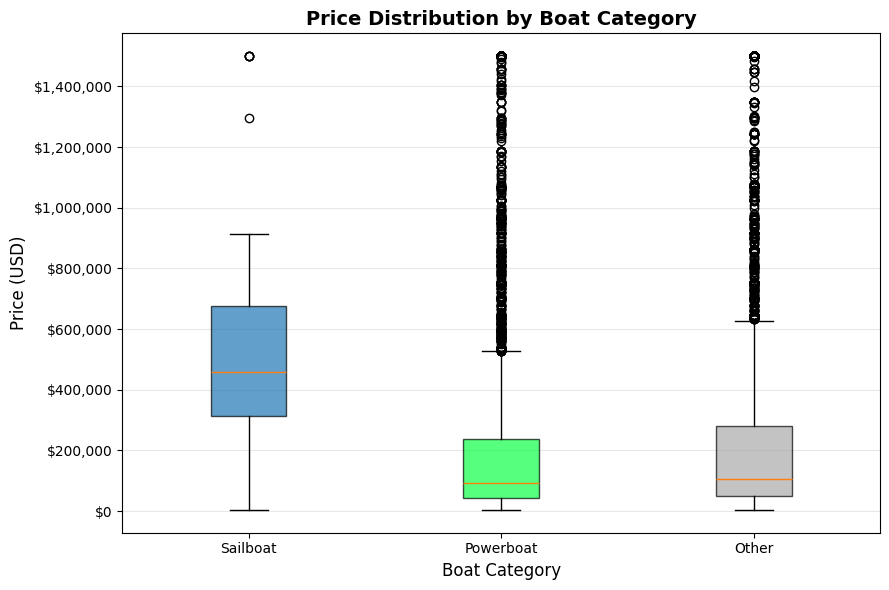

CHART 4 INTERPRETATION:
This box plot shows the spread of prices within each boat category.
The box shows where the middle 50% of prices fall; the line inside is the median.
Dots outside the whiskers are outlier listings — unusually expensive or cheap boats.


In [31]:
# --- Chart 4: Price Distribution by Boat Category (Box Plot) ---
fig, ax = plt.subplots(figsize=(9, 6))
categories = ['Sailboat', 'Powerboat', 'Other']
data_to_plot = [df_clean[df_clean['Boat Category'] == cat]['Price_USD'].clip(upper=1_500_000).dropna().values
                for cat in categories]
bp = ax.boxplot(data_to_plot, labels=categories, patch_artist=True, notch=False)
box_colors = ['#1f77b4', "#0eff46", '#aaaaaa']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Price Distribution by Boat Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Boat Category', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart4_price_boxplot.png', dpi=150)
plt.show()
print('CHART 4 INTERPRETATION:')
print('This box plot shows the spread of prices within each boat category.')
print('The box shows where the middle 50% of prices fall; the line inside is the median.')
print('Dots outside the whiskers are outlier listings — unusually expensive or cheap boats.')

In [32]:
# findings, limitations & conclusions
print('='*60)
print('KEY FINDINGS')
print('='*60)

print(f'''
Finding 1 — Price by category:
  {cat_price.idxmax()} boats have the highest average listing price
  at ${cat_price.max():,.0f}, compared to ${cat_price.min():,.0f} for
  {cat_price.idxmin()} boats. This suggests significant price differences
  between boat types on the market.

Finding 2 — Length and price relationship:
  The Pearson correlation between length and price is {correlation:.2f},
  indicating a {'strong' if abs(correlation) > 0.5 else 'moderate'} positive
  relationship. Longer boats consistently command higher prices.

Finding 3 — Outlier listings:
  {len(outliers)} boat listings were identified as statistical outliers
  with z-scores above 3. These extreme prices likely represent luxury yachts
  or data entry errors and should be excluded from general analysis.

Finding 4 — Geographic pricing differences:
  The top-priced country averages significantly higher than the dataset
  overall, suggesting that some markets list premium boats more frequently.

Finding 5 — Buyer interest (views):
  {views_by_cat.idxmax()} boats receive the most average views per week,
  at {views_by_cat.max():.1f} views. This signals stronger buyer demand
  for this category in the current market.
''')

print('='*60)
print('LIMITATIONS')
print('='*60)
print('''
1. Currency conversion used approximate historical exchange rates,
   which may not reflect exact values at the time of listing.

2. Missing values in Material and Width were handled with fill strategies
   that may introduce small biases into group comparisons.

3. The dataset only reflects listed prices, not actual sale prices,
   so true market value may differ.

4. Correlation does not imply causation — length correlates with price
   but other factors (brand, condition, age) also play major roles.

5. The boat category classification is rule-based and may misclassify
   niche boat types not matching the defined keywords.
''')

print('='*60)
print('CONCLUSION')
print('='*60)
print('''
This analysis of the Boat Sales dataset revealed meaningful patterns
in how boat type, size, and geography influence listing prices and
buyer interest. Boat length is a reliable predictor of price, with
a positive correlation confirmed through statistical analysis.
Significant price outliers exist and were detected using NumPy z-scores.
Future work could include normalizing prices for boat condition and
incorporating actual sale data to better reflect true market dynamics.
''')

KEY FINDINGS

Finding 1 — Price by category:
  Sailboat boats have the highest average listing price
  at $773,335, compared to $261,882 for
  Powerboat boats. This suggests significant price differences
  between boat types on the market.

Finding 2 — Length and price relationship:
  The Pearson correlation between length and price is 0.62,
  indicating a strong positive
  relationship. Longer boats consistently command higher prices.

Finding 3 — Outlier listings:
  166 boat listings were identified as statistical outliers
  with z-scores above 3. These extreme prices likely represent luxury yachts
  or data entry errors and should be excluded from general analysis.

Finding 4 — Geographic pricing differences:
  The top-priced country averages significantly higher than the dataset
  overall, suggesting that some markets list premium boats more frequently.

Finding 5 — Buyer interest (views):
  Sailboat boats receive the most average views per week,
  at 165.5 views. This signals stro